# 03 — Training runner

This notebook runs training from a selected config. The notebook itself
is shared for all experiments; the chosen config string selects the
run.

If you want parallel work, open multiple Colab sessions on the same
notebook and each session picks a different `RUN` value.


In [1]:
# GPU sanity check — run BEFORE launching training.
# Expected on a clean runtime: no processes listed, ~0 MiB used.
# If a stale process is holding memory: Runtime -> Disconnect and delete
# runtime (a plain restart is NOT enough - the VM must go), then rerun.
!nvidia-smi

import torch
free, total = torch.cuda.mem_get_info()
print(f"\nfree: {free/2**30:.2f} GiB / total: {total/2**30:.2f} GiB")
assert free / 2**30 > 10, (
"GPU is not clean: less than 10 GiB free before training. "
"Something else is holding memory - delete the runtime and start over. "
"Do NOT reduce batch_size: the phase-A gate measured 8.57 GiB peak at "
"full batch, C3 fits a clean T4 with margin."
)
print("GPU clean - OK to launch.") #fai girare prima della cella di training

Fri Jul 17 09:54:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Environment setup

This notebook is not one run per file. Instead:

- one notebook = one runner
- one config = one experiment
- different people can use the same notebook with different config values

In Colab, the notebook runs on a remote VM. If the repo is not already
available there, this notebook will clone it from GitHub. It also stages
data from the shared Drive archive into `/content/data` using the
paths defined in `configs/paths.yaml`.


In [2]:
from pathlib import Path
import subprocess
import sys
import torch
import zipfile

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Locate or clone the repository root containing the sharp_har package.
# In Colab, the notebook may run from a temporary working directory.
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
elif (cwd.parent.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

# After the clone, so the file actually exists on a fresh runtime.
!pip install -q -r {REPO_DIR}/requirements.txt

sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.train import train_run
from sharp_har.utils import read_yaml

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
drive_root = Path(paths_cfg["drive_root"])
stage_dir = Path(paths_cfg["stage_dir"])
CKPT_ROOT = Path(paths_cfg["ckpt_root"])

# Mount Drive unconditionally (idempotent): checkpoints are written to
# CKPT_ROOT on Drive even when the data is already staged on the VM.
drive.mount("/content/drive")

# Stage the zip archives if needed (same convention as 00_setup_smoke).
if not (stage_dir.exists() and any(stage_dir.rglob("*.txt"))):
    stage_dir.mkdir(parents=True, exist_ok=True)
    for zip_name in paths_cfg["zips"]:
        src = drive_root / zip_name
        dst = Path("/content") / zip_name
        print(f"copying {src} -> {dst}")
        subprocess.run(["cp", str(src), str(dst)], check=True)
        with zipfile.ZipFile(dst) as zf:
            zf.extractall(stage_dir)

print("Repo dir:", REPO_DIR)
print("sharp_har exists:", (REPO_DIR / "sharp_har").exists())
print("GPU available:", torch.cuda.is_available())
print("Stage dir:", stage_dir)
print("Checkpoint root:", CKPT_ROOT)


Mounted at /content/drive
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip -> /content/doppler_traces.zip
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces_S4_S5.zip -> /content/doppler_traces_S4_S5.zip
Repo dir: /content/sharp-har
sharp_har exists: True
GPU available: True
Stage dir: /content/data
Checkpoint root: /content/drive/MyDrive/sharp_har_runs


## Load config and launch the run

Choose one config stem below and run the cell. The config name
determines which experiment is executed.


In [ ]:
RUN = "c3_supcon"  # choose one of c0_sharp, c1_ce, c2_grl, c3_supcon, c4_supcon_grl
cfg = read_yaml(REPO_DIR / "configs" / f"{RUN}.yaml")

print("Selected run:", RUN)
print("Config summary:")
print(cfg)

out = train_run(cfg, stage_dir=stage_dir, ckpt_dir=CKPT_ROOT, repo_dir=REPO_DIR)
print("Train run finished:", out)


2026-07-17 09:57:09,129 [INFO] sharp_har.data: train: 81 traces, 53400 (window, antenna) samples (win=340, stride=100)
2026-07-17 09:57:09,144 [INFO] sharp_har.data: val: 9 traces, 1396 (window, antenna) samples (win=340, stride=340)


Selected run: c3_supcon
Config summary:
{'name': 'C3', 'protocol': 'P2-lab', 'split_file': 'splits/p2_lab.json', 'backbone': 'resnet_vb', 'd_enc': 256, 'n_att': 8, 'loss': {'type': 'supcon', 'tau': 0.1, 'label_smoothing': None}, 'adversary': {'type': None, 'target': 'ar_set', 'lambda_max': None, 'beta': None}, 'optim': {'name': 'adamw', 'lr': 0.001, 'wd': 0.0001, 'warmup_epochs': 5, 'scheduler': 'cosine'}, 'train': {'epoch_steps': 300, 'max_epochs': 60, 'checkpoint_epochs': [40, 50, 60], 'batch_size': 256, 'sampler': 'pxk', 'amp': True, 'grad_clip': 1.0}, 'eval': {'select_metric': 'val_macro_f1', 'patience': None}}


2026-07-17 09:57:18,817 [INFO] sharp_har.train: resumed C3 from /content/drive/MyDrive/sharp_har_runs/C3/last.ckpt at epoch 26
2026-07-17 10:02:53,413 [INFO] sharp_har.sampler: P×K epoch 26: 300 batches, 52704 trace reuses (min offset 400; window 340)
2026-07-17 10:02:57,410 [INFO] sharp_har.train: C3 epoch 26/60: loss 4.7816, 1.128 s/step
2026-07-17 10:08:15,790 [INFO] sharp_har.sampler: P×K epoch 27: 300 batches, 52695 trace reuses (min offset 400; window 340)
2026-07-17 10:08:19,790 [INFO] sharp_har.train: C3 epoch 27/60: loss 4.7564, 1.068 s/step
2026-07-17 10:13:35,081 [INFO] sharp_har.sampler: P×K epoch 28: 300 batches, 52701 trace reuses (min offset 400; window 340)
2026-07-17 10:13:39,098 [INFO] sharp_har.train: C3 epoch 28/60: loss 4.7363, 1.062 s/step
2026-07-17 10:18:53,679 [INFO] sharp_har.sampler: P×K epoch 29: 300 batches, 52693 trace reuses (min offset 400; window 340)
2026-07-17 10:18:57,700 [INFO] sharp_har.train: C3 epoch 29/60: loss 4.7197, 1.058 s/step
2026-07-17 10

## Training curves

Per-epoch diagnostics read from the run's `history.csv` (§0.4). The
panels adapt to the run: train loss and throughput always; fused val
macro-F1 with the val-selected best epoch on CE runs (C0/C1/C2); the
mandatory §6-C2 GRL monitoring pair (AR-set train accuracy vs λ ramp)
on C2/C4; learning rate. Re-run this cell any time — it re-reads the
CSV, so it also works on a resumed or still-running run.

Related helpers in `sharp_har.viz`: `plot_confusion(csv)` for the
harness `*_confusion.csv` files, `compare_runs({name: run_dir, ...})`
to overlay a metric across configs (remember §0.5: differences under
~2 points are "comparable", not improvements).


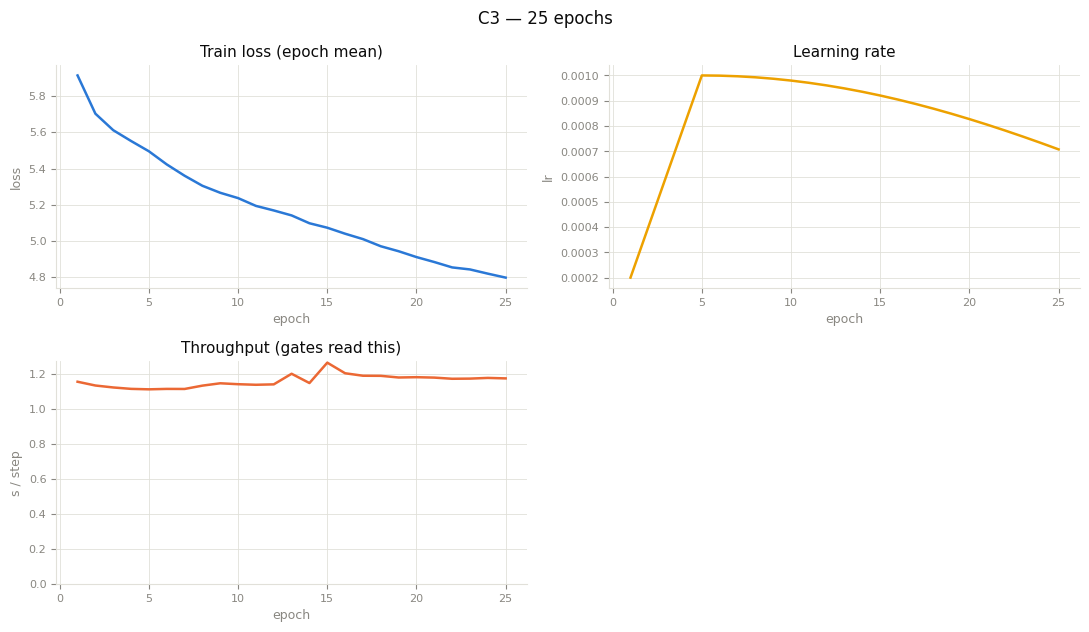

In [ ]:
# Thin runner: all plotting logic lives in sharp_har.viz.
from sharp_har.viz import plot_history

run_dir = CKPT_ROOT / cfg["name"]
plot_history(run_dir);


## Archiving the definitive run notebook

This notebook stays a **clean template** (outputs cleared on Git). The
executed copy of a real run is a measured artifact and is committed
verbatim, like the gate reports:

1. When the run (or a resumed segment) ends, download the executed
   notebook (`File → Download → .ipynb`) **with its outputs**.
2. Commit it under `notebooks/runs/` as `YYYY-MM-DD_<config>.ipynb`
   (e.g. `2026-07-16_c0_sharp.ipynb`); add a `_partN` suffix if one run
   spans several resumed sessions. Never edit archived outputs.
3. The run's numeric artifacts still live in `ckpt_root/<name>/`
   (`history.csv`, `run_meta.json`, checkpoints) — the archived
   notebook is the human-readable record, not a data source.

See `notebooks/runs/README.md` for the full convention.
